In [2]:

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Machine Learning - Preprocessing
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler

# Classification Algorithms
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier

# Evaluation Metrics
from sklearn.model_selection import KFold, cross_val_score
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    roc_auc_score,
    RocCurveDisplay
)

# Reproducibility
RANDOM_STATE = 42

print("Libraries imported successfully!")

Libraries imported successfully!


In [5]:

# 2. LOAD DATASET


file_path = "../data/diabetes_binary_health_indicators_BRFSS2015.csv"

df = pd.read_csv(file_path)

print("Dataset loaded successfully!")
print(f"Dataset shape: {df.shape}")

Dataset loaded successfully!
Dataset shape: (253680, 22)


In [6]:
# ============================================================
# 3. BASIC DATASET OVERVIEW
# ============================================================

print("First 5 rows:")
display(df.head())

print("\nDataset information:")
df.info()

First 5 rows:


,Diabetes_binary,HighBP,HighChol,CholCheck,BMI,Smoker,Stroke,HeartDiseaseorAttack,PhysActivity,Fruits,...,AnyHealthcare,NoDocbcCost,GenHlth,MentHlth,PhysHlth,DiffWalk,Sex,Age,Education,Income
0,0.0,1.0,1.0,1.0,40.0,1.0,0.0,0.0,0.0,0.0,...,1.0,0.0,5.0,18.0,15.0,1.0,0.0,9.0,4.0,3.0
1,0.0,0.0,0.0,0.0,25.0,1.0,0.0,0.0,1.0,0.0,...,0.0,1.0,3.0,0.0,0.0,0.0,0.0,7.0,6.0,1.0
2,0.0,1.0,1.0,1.0,28.0,0.0,0.0,0.0,0.0,1.0,...,1.0,1.0,5.0,30.0,30.0,1.0,0.0,9.0,4.0,8.0
3,0.0,1.0,0.0,1.0,27.0,0.0,0.0,0.0,1.0,1.0,...,1.0,0.0,2.0,0.0,0.0,0.0,0.0,11.0,3.0,6.0
4,0.0,1.0,1.0,1.0,24.0,0.0,0.0,0.0,1.0,1.0,...,1.0,0.0,2.0,3.0,0.0,0.0,0.0,11.0,5.0,4.0



Dataset information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 253680 entries, 0 to 253679
Data columns (total 22 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   Diabetes_binary       253680 non-null  float64
 1   HighBP                253680 non-null  float64
 2   HighChol              253680 non-null  float64
 3   CholCheck             253680 non-null  float64
 4   BMI                   253680 non-null  float64
 5   Smoker                253680 non-null  float64
 6   Stroke                253680 non-null  float64
 7   HeartDiseaseorAttack  253680 non-null  float64
 8   PhysActivity          253680 non-null  float64
 9   Fruits                253680 non-null  float64
 10  Veggies               253680 non-null  float64
 11  HvyAlcoholConsump     253680 non-null  float64
 12  AnyHealthcare         253680 non-null  float64
 13  NoDocbcCost           253680 non-null  float64
 14  GenHlth               253680 n

In [7]:
# ============================================================
# 4. MISSING VALUE CHECK
# ============================================================

missing_values = df.isnull().sum()

print("Missing values in each column:")
display(missing_values)

print(f"\nTotal missing values: {missing_values.sum()}")

Missing values in each column:


Diabetes_binary         0
HighBP                  0
HighChol                0
CholCheck               0
BMI                     0
Smoker                  0
Stroke                  0
HeartDiseaseorAttack    0
PhysActivity            0
Fruits                  0
Veggies                 0
HvyAlcoholConsump       0
AnyHealthcare           0
NoDocbcCost             0
GenHlth                 0
MentHlth                0
PhysHlth                0
DiffWalk                0
Sex                     0
Age                     0
Education               0
Income                  0
dtype: int64


Total missing values: 0


In [8]:
# ============================================================
# 5. DUPLICATE CHECK
# ============================================================

duplicate_count = df.duplicated().sum()

print(f"Number of duplicate rows: {duplicate_count}")

Number of duplicate rows: 24206


In [9]:
# ============================================================
# 6. DUPLICATE ANALYSIS
# ============================================================

print("Duplicate rows:", df.duplicated().sum())

# Number of rows remaining after removing duplicates
df_no_duplicates = df.drop_duplicates()

print("Rows before removing duplicates:", len(df))
print("Rows after removing duplicates:", len(df_no_duplicates))
print("Rows removed:", len(df) - len(df_no_duplicates))

Duplicate rows: 24206
Rows before removing duplicates: 253680
Rows after removing duplicates: 229474
Rows removed: 24206


In [10]:
# ============================================================
# 7. TARGET DISTRIBUTION
# ============================================================

target_counts = df["Diabetes_binary"].value_counts().sort_index()
target_percentages = (
    df["Diabetes_binary"]
    .value_counts(normalize=True)
    .sort_index() * 100
)

target_distribution = pd.DataFrame({
    "Count": target_counts,
    "Percentage": target_percentages.round(2)
})

display(target_distribution)

,Count,Percentage
Diabetes_binary,,
0.0,218334,86.07
1.0,35346,13.93


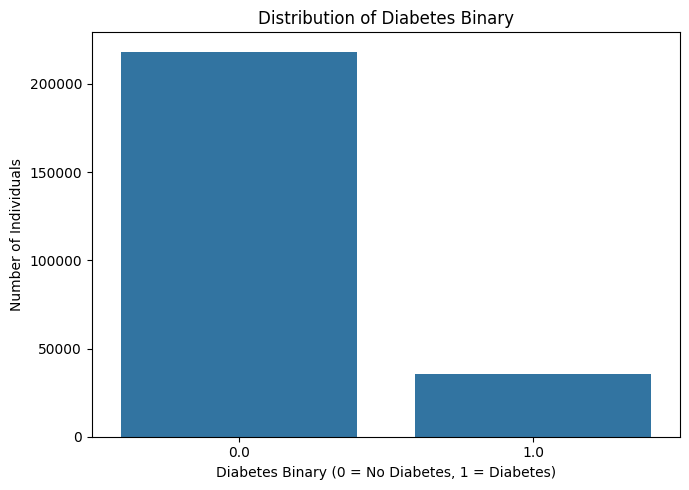

In [11]:
# Target distribution visualization

plt.figure(figsize=(7, 5))

sns.countplot(
    data=df,
    x="Diabetes_binary"
)

plt.title("Distribution of Diabetes Binary")
plt.xlabel("Diabetes Binary (0 = No Diabetes, 1 = Diabetes)")
plt.ylabel("Number of Individuals")

plt.tight_layout()
plt.show()

In [12]:
# ============================================================
# 8. REMOVE DUPLICATE ROWS
# ============================================================

print("Shape before removing duplicates:", df.shape)

df = df.drop_duplicates().reset_index(drop=True)

print("Shape after removing duplicates:", df.shape)

print(f"Rows removed: {253680 - len(df)}")

Shape before removing duplicates: (253680, 22)
Shape after removing duplicates: (229474, 22)
Rows removed: 24206


In [13]:
# ============================================================
# 9. VERIFY DATA CLEANING
# ============================================================

print("Missing values:", df.isnull().sum().sum())
print("Duplicate rows:", df.duplicated().sum())
print("Final dataset shape:", df.shape)

Missing values: 0
Duplicate rows: 0
Final dataset shape: (229474, 22)


In [14]:
# ============================================================
# 10. STATISTICAL SUMMARY
# ============================================================

pd.set_option("display.max_columns", None)

display(df.describe().T)

,count,mean,std,min,25%,50%,75%,max
Diabetes_binary,229474.0,0.152945,0.359936,0.0,0.0,0.0,0.0,1.0
HighBP,229474.0,0.454343,0.497912,0.0,0.0,0.0,1.0,1.0
HighChol,229474.0,0.441640,0.496584,0.0,0.0,0.0,1.0,1.0
CholCheck,229474.0,0.959481,0.197173,0.0,1.0,1.0,1.0,1.0
BMI,229474.0,28.687507,6.789204,12.0,24.0,27.0,32.0,98.0
Smoker,229474.0,0.465800,0.498830,0.0,0.0,0.0,1.0,1.0
Stroke,229474.0,0.044816,0.206899,0.0,0.0,0.0,0.0,1.0
HeartDiseaseorAttack,229474.0,0.103336,0.304398,0.0,0.0,0.0,0.0,1.0
PhysActivity,229474.0,0.733042,0.442371,0.0,0.0,1.0,1.0,1.0
Fruits,229474.0,0.612675,0.487140,0.0,0.0,1.0,1.0,1.0


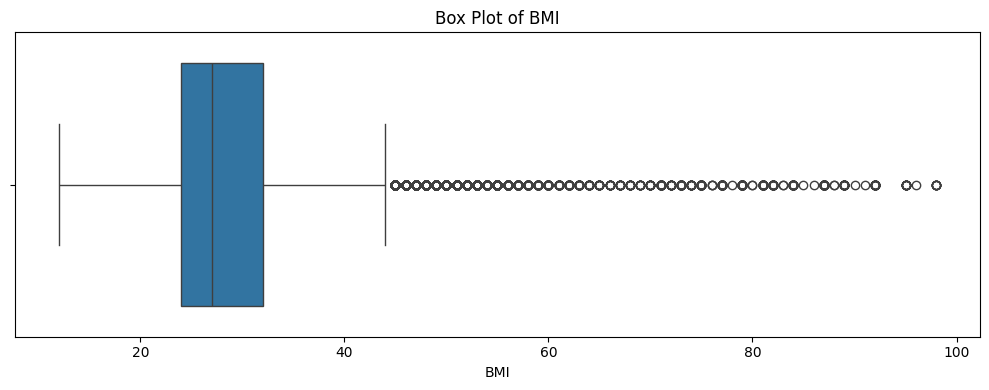

Minimum BMI: 12.0
Maximum BMI: 98.0
Mean BMI: 28.69
Median BMI: 27.0


In [15]:
# ============================================================
# 11. BMI OUTLIER ANALYSIS
# ============================================================

plt.figure(figsize=(10, 4))

sns.boxplot(x=df["BMI"])

plt.title("Box Plot of BMI")
plt.xlabel("BMI")

plt.tight_layout()
plt.show()

print("Minimum BMI:", df["BMI"].min())
print("Maximum BMI:", df["BMI"].max())
print("Mean BMI:", round(df["BMI"].mean(), 2))
print("Median BMI:", df["BMI"].median())

In [16]:
# ============================================================
# 12. BMI IQR OUTLIER DETECTION
# ============================================================

Q1 = df["BMI"].quantile(0.25)
Q3 = df["BMI"].quantile(0.75)

IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

bmi_outliers = df[
    (df["BMI"] < lower_bound) |
    (df["BMI"] > upper_bound)
]

print("Q1:", Q1)
print("Q3:", Q3)
print("IQR:", IQR)
print("Lower bound:", lower_bound)
print("Upper bound:", upper_bound)

print("Potential BMI outliers:", len(bmi_outliers))
print(
    "Percentage of potential outliers:",
    round(len(bmi_outliers) / len(df) * 100, 2),
    "%"
)

Q1: 24.0
Q3: 32.0
IQR: 8.0
Lower bound: 12.0
Upper bound: 44.0
Potential BMI outliers: 5638
Percentage of potential outliers: 2.46 %


In [17]:
# ============================================================
# 13. FEATURE GROUPING
# ============================================================

binary_features = [
    "HighBP",
    "HighChol",
    "CholCheck",
    "Smoker",
    "Stroke",
    "HeartDiseaseorAttack",
    "PhysActivity",
    "Fruits",
    "Veggies",
    "HvyAlcoholConsump",
    "AnyHealthcare",
    "NoDocbcCost",
    "DiffWalk",
    "Sex"
]

numeric_features = [
    "BMI",
    "GenHlth",
    "MentHlth",
    "PhysHlth",
    "Age",
    "Education",
    "Income"
]

print("Number of binary features:", len(binary_features))
print("Number of numeric/ordinal features:", len(numeric_features))

Number of binary features: 14
Number of numeric/ordinal features: 7


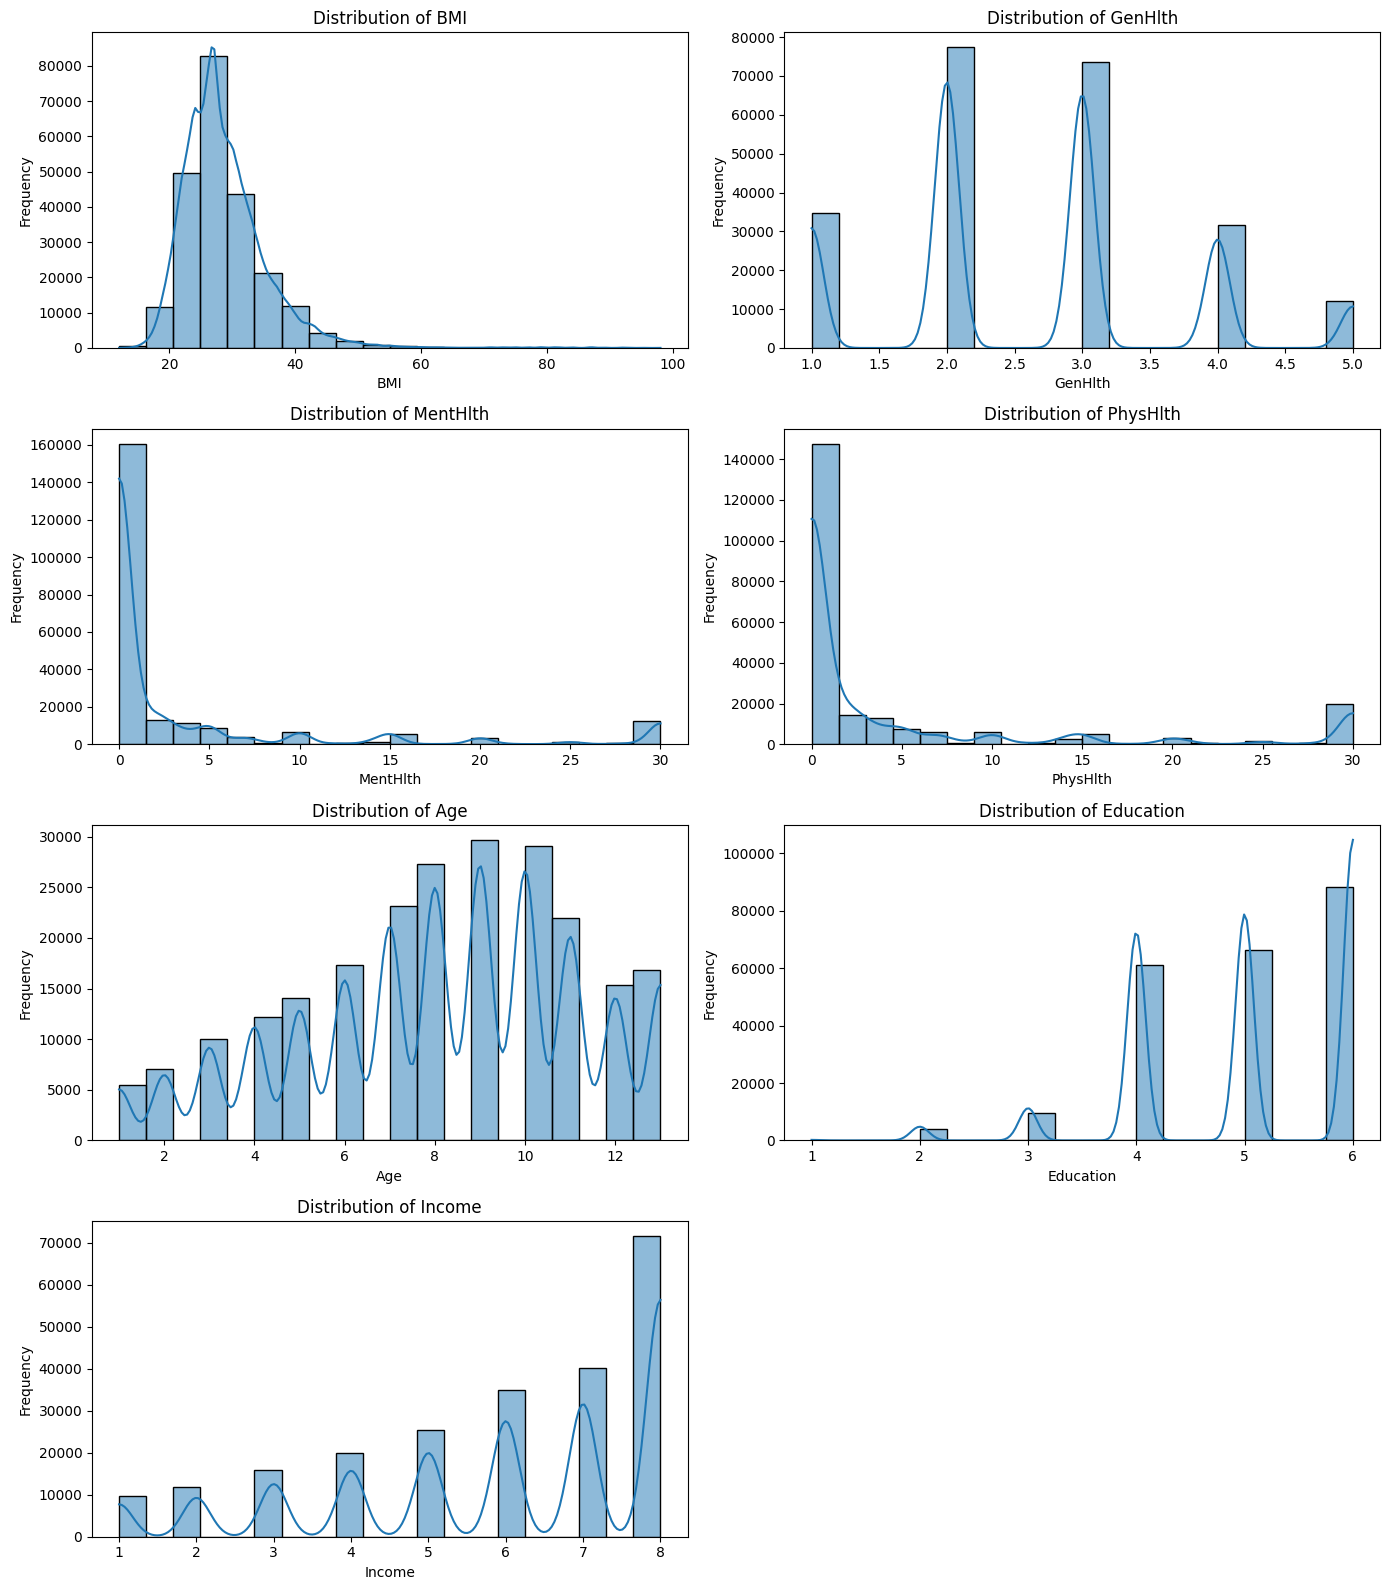

In [18]:
# ============================================================
# 14. DISTRIBUTION OF NUMERIC/ORDINAL FEATURES
# ============================================================

fig, axes = plt.subplots(4, 2, figsize=(14, 16))

for ax, feature in zip(axes.flatten(), numeric_features):
    sns.histplot(
        data=df,
        x=feature,
        bins=20,
        kde=True,
        ax=ax
    )
    ax.set_title(f"Distribution of {feature}")
    ax.set_xlabel(feature)
    ax.set_ylabel("Frequency")

# Hide unused subplot
axes.flatten()[-1].set_visible(False)

plt.tight_layout()
plt.show()

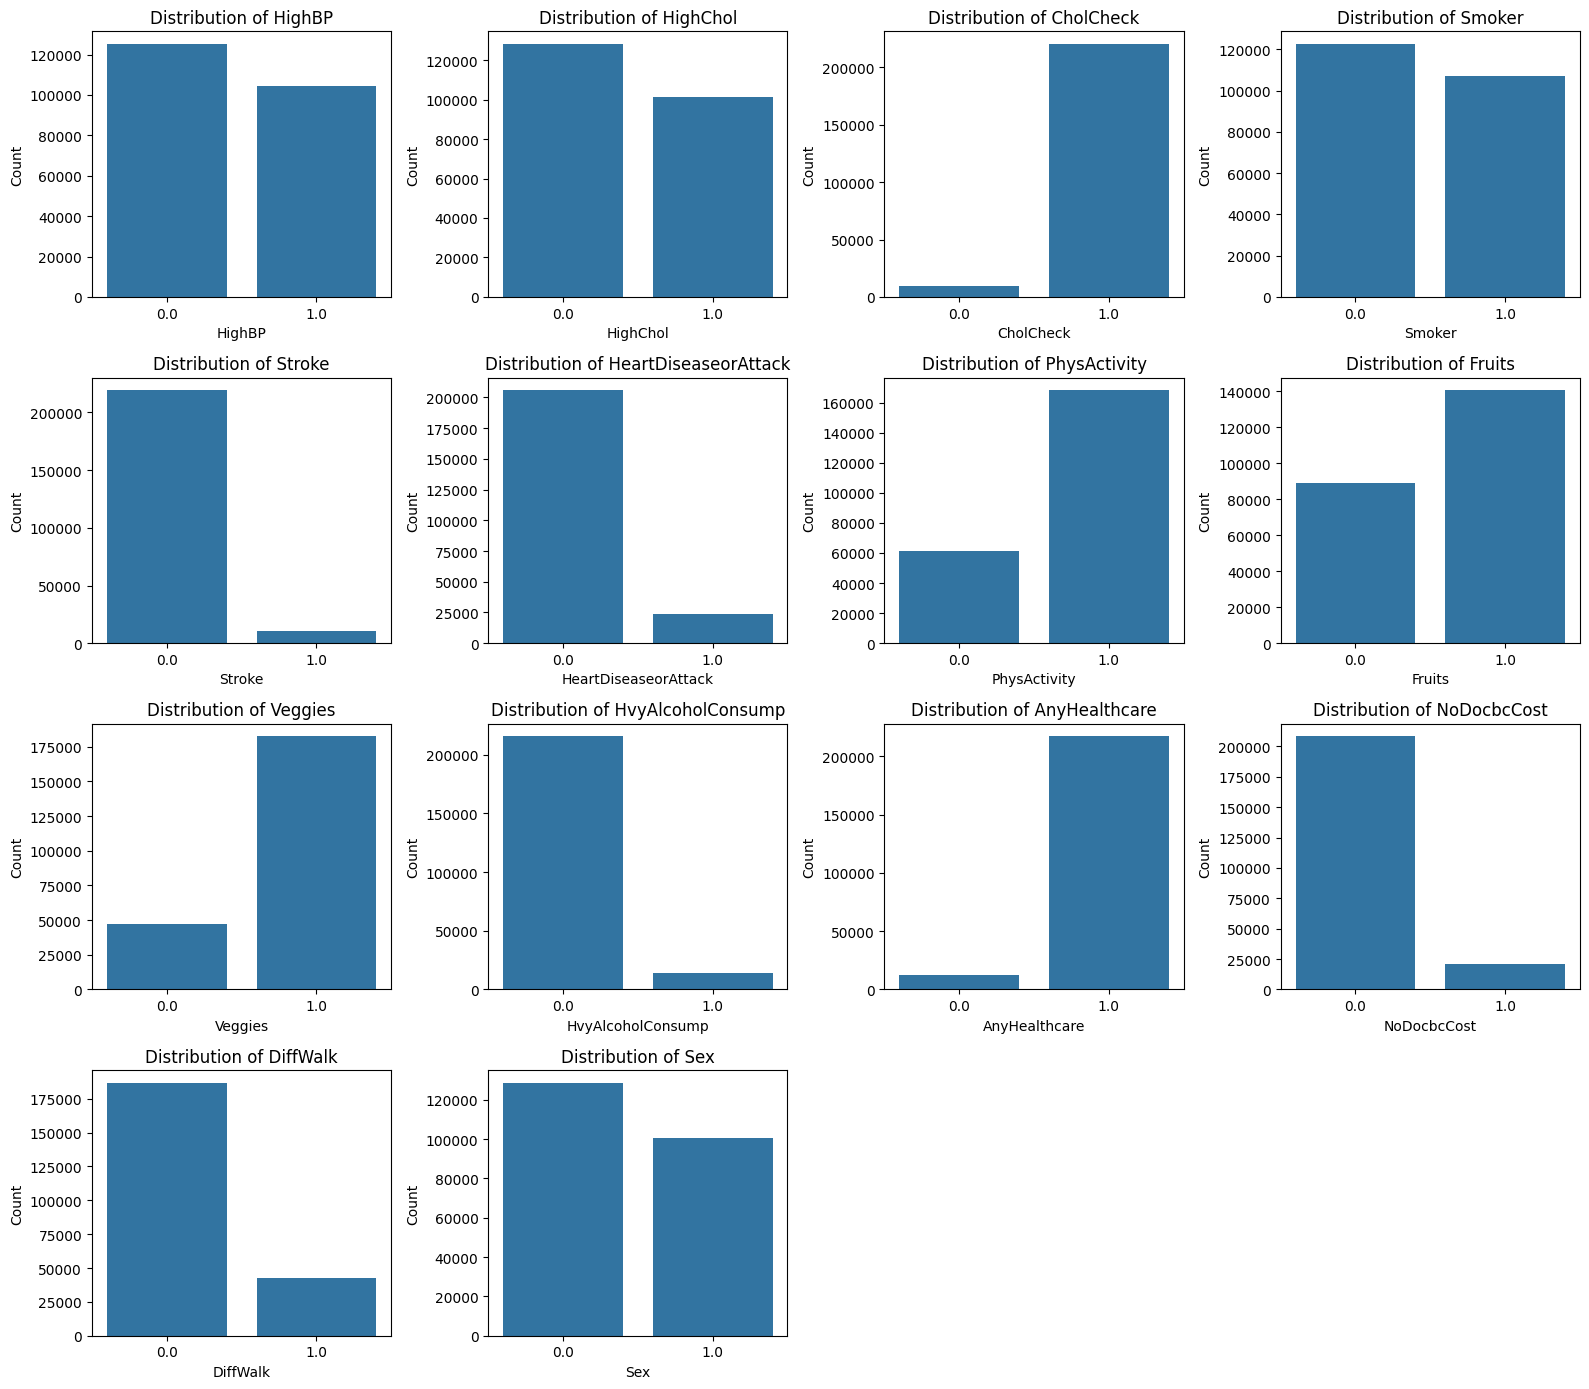

In [19]:
# ============================================================
# 15. DISTRIBUTION OF BINARY FEATURES
# ============================================================

fig, axes = plt.subplots(4, 4, figsize=(16, 14))

for ax, feature in zip(axes.flatten(), binary_features):
    sns.countplot(
        data=df,
        x=feature,
        ax=ax
    )
    ax.set_title(f"Distribution of {feature}")
    ax.set_xlabel(feature)
    ax.set_ylabel("Count")

# Hide unused subplot
for ax in axes.flatten()[len(binary_features):]:
    ax.set_visible(False)

plt.tight_layout()
plt.show()

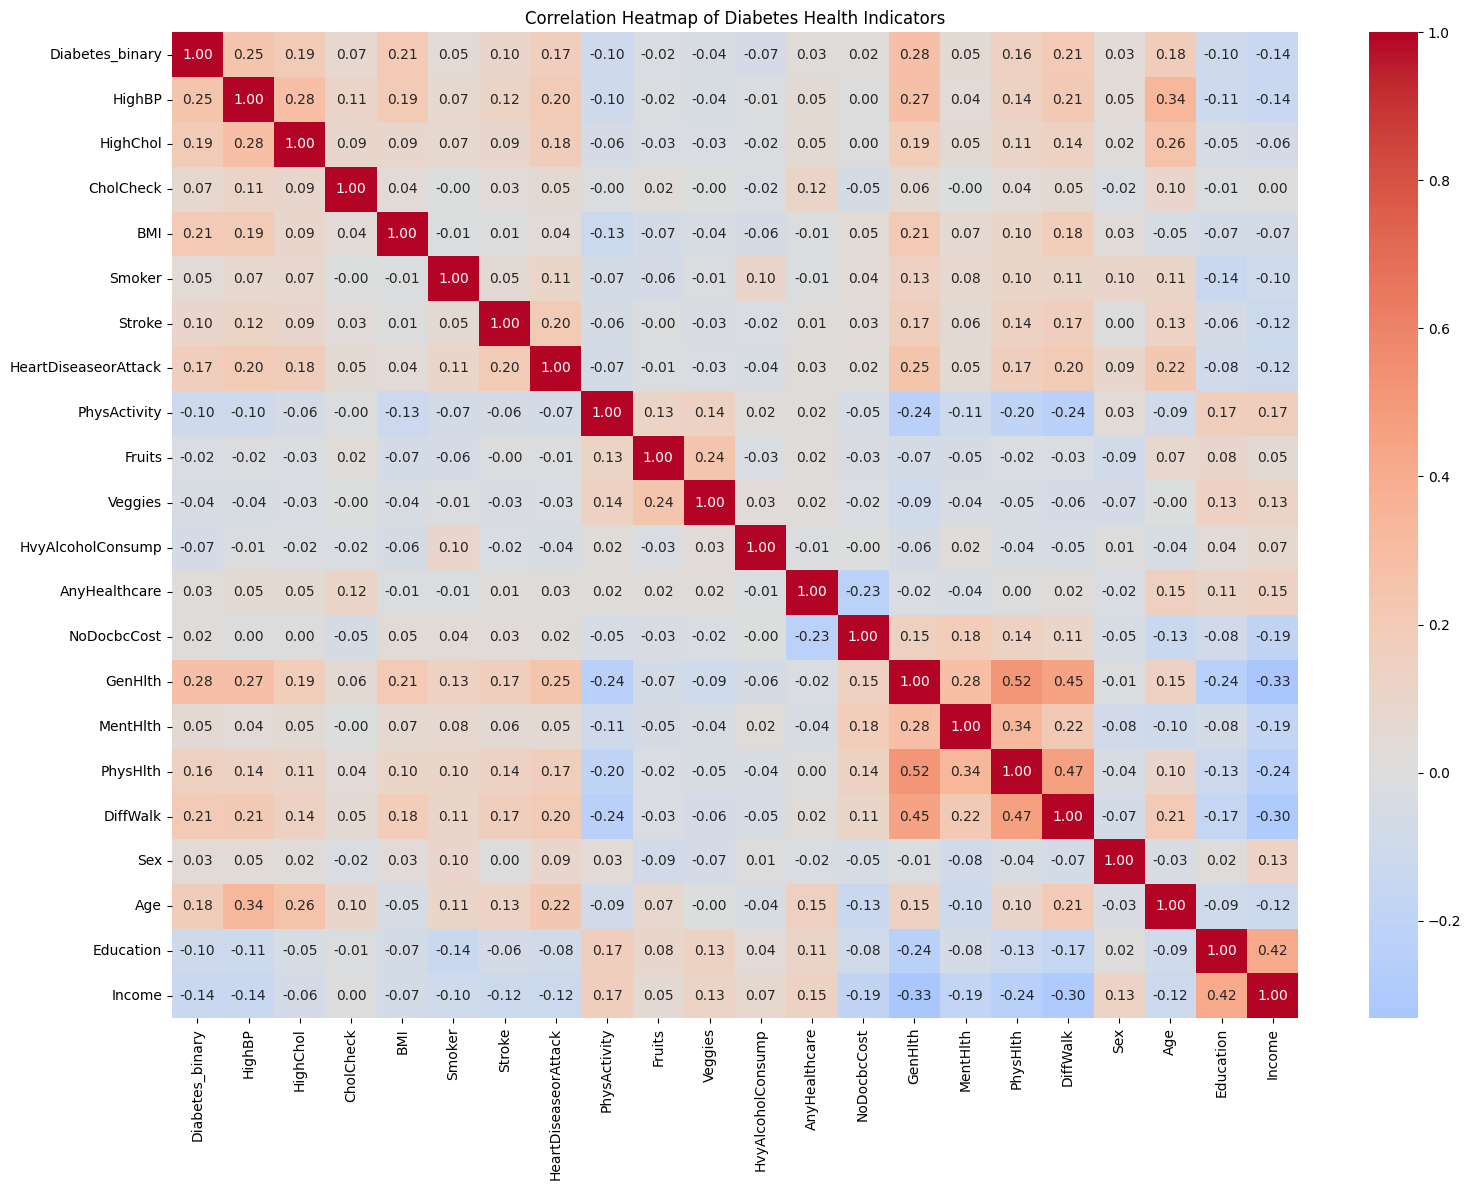

In [20]:
# ============================================================
# 16. CORRELATION HEATMAP
# ============================================================

correlation_matrix = df.corr()

plt.figure(figsize=(16, 12))

sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0
)

plt.title("Correlation Heatmap of Diabetes Health Indicators")
plt.tight_layout()
plt.show()

In [21]:
# ============================================================
# 17. FEATURE CORRELATION WITH TARGET
# ============================================================

target_correlations = (
    df.corr()["Diabetes_binary"]
    .drop("Diabetes_binary")
    .sort_values(ascending=False)
)

display(target_correlations.to_frame("Correlation with Diabetes_binary"))

,Correlation with Diabetes_binary
GenHlth,0.276940
HighBP,0.254318
DiffWalk,0.205302
BMI,0.205086
HighChol,0.194944
Age,0.177263
HeartDiseaseorAttack,0.168213
PhysHlth,0.156211
Stroke,0.099193
CholCheck,0.072523


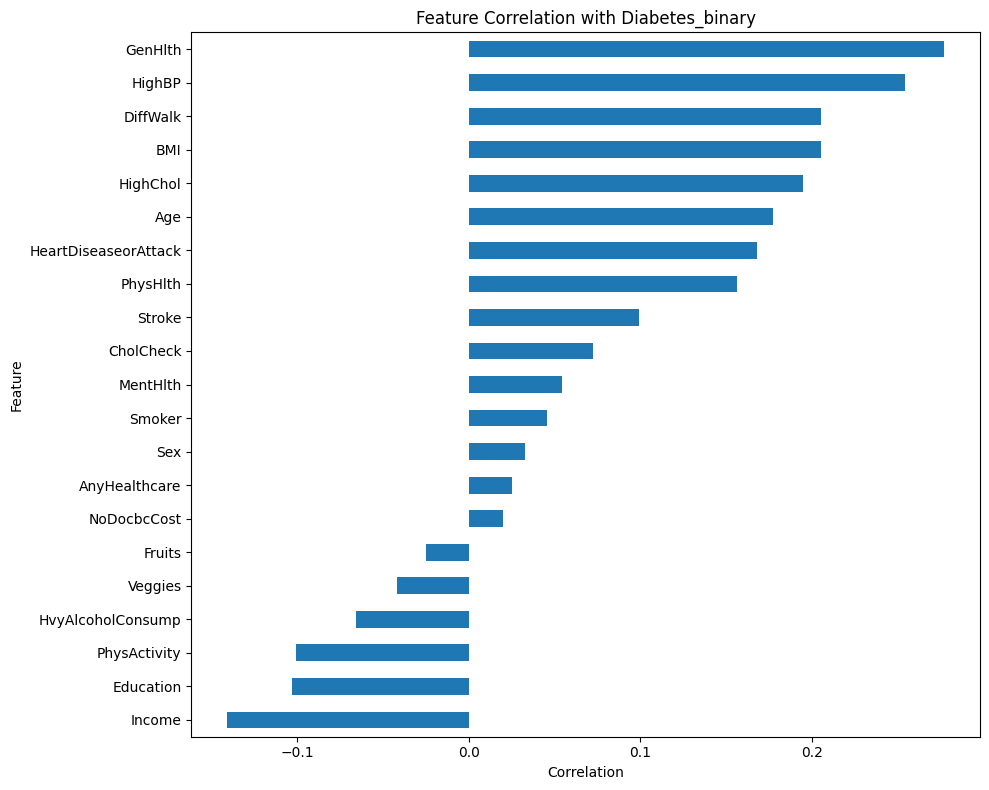

In [22]:
# Plot feature correlations with target

plt.figure(figsize=(10, 8))

target_correlations.sort_values().plot(
    kind="barh"
)

plt.title("Feature Correlation with Diabetes_binary")
plt.xlabel("Correlation")
plt.ylabel("Feature")

plt.tight_layout()
plt.show()

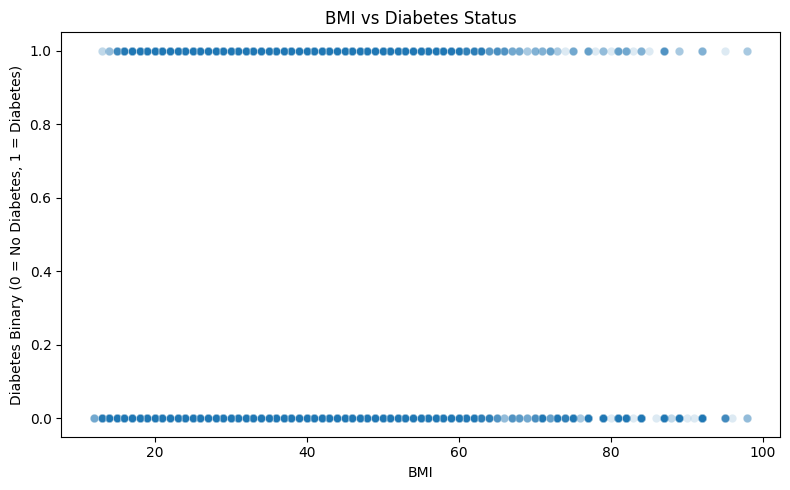

In [23]:
# ============================================================
# 18. BMI VS DIABETES
# ============================================================

plt.figure(figsize=(8, 5))

sns.scatterplot(
    data=df,
    x="BMI",
    y="Diabetes_binary",
    alpha=0.15
)

plt.title("BMI vs Diabetes Status")
plt.xlabel("BMI")
plt.ylabel("Diabetes Binary (0 = No Diabetes, 1 = Diabetes)")

plt.tight_layout()
plt.show()

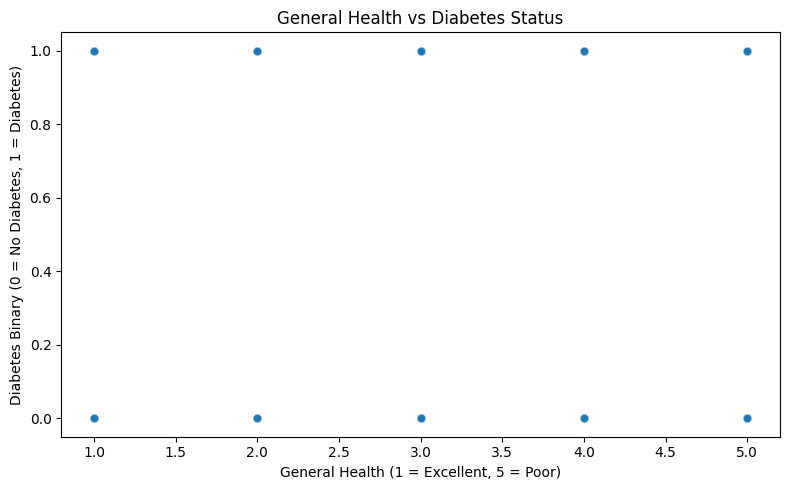

In [24]:
# ============================================================
# 19. GENERAL HEALTH VS DIABETES
# ============================================================

plt.figure(figsize=(8, 5))

sns.scatterplot(
    data=df,
    x="GenHlth",
    y="Diabetes_binary",
    alpha=0.15
)

plt.title("General Health vs Diabetes Status")
plt.xlabel("General Health (1 = Excellent, 5 = Poor)")
plt.ylabel("Diabetes Binary (0 = No Diabetes, 1 = Diabetes)")

plt.tight_layout()
plt.show()


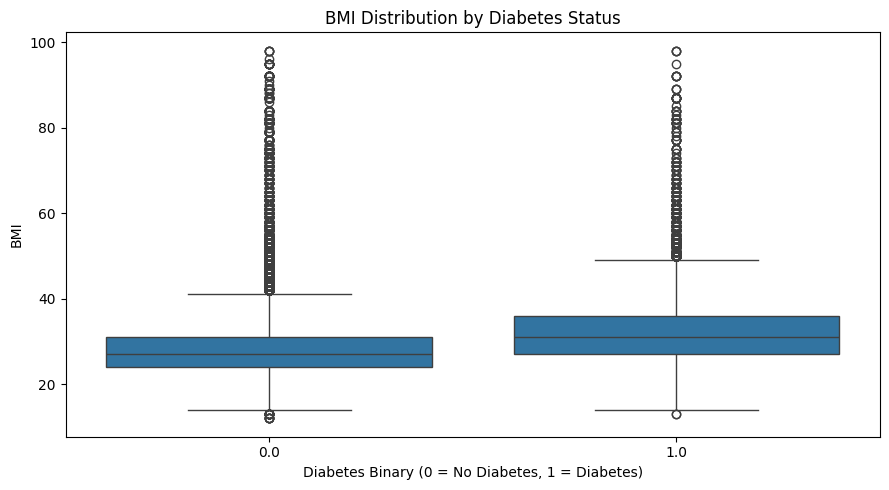

In [25]:
# ============================================================
# 20. BMI DISTRIBUTION BY DIABETES STATUS
# ============================================================

plt.figure(figsize=(9, 5))

sns.boxplot(
    data=df,
    x="Diabetes_binary",
    y="BMI"
)

plt.title("BMI Distribution by Diabetes Status")
plt.xlabel("Diabetes Binary (0 = No Diabetes, 1 = Diabetes)")
plt.ylabel("BMI")

plt.tight_layout()
plt.show()

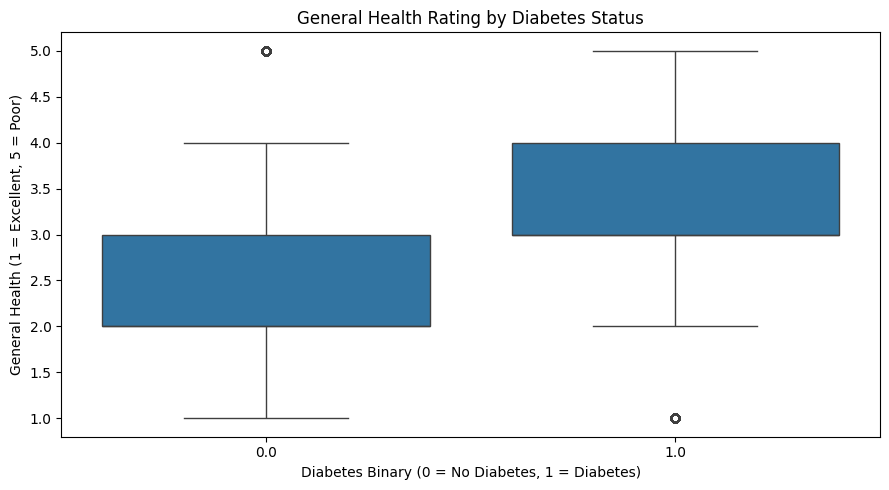

In [26]:
# ============================================================
# 21. GENERAL HEALTH BY DIABETES STATUS
# ============================================================

plt.figure(figsize=(9, 5))

sns.boxplot(
    data=df,
    x="Diabetes_binary",
    y="GenHlth"
)

plt.title("General Health Rating by Diabetes Status")
plt.xlabel("Diabetes Binary (0 = No Diabetes, 1 = Diabetes)")
plt.ylabel("General Health (1 = Excellent, 5 = Poor)")

plt.tight_layout()
plt.show()

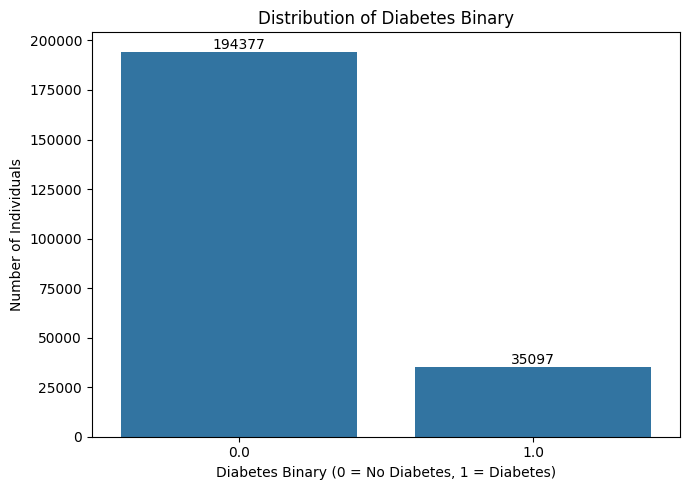

In [27]:
 # ============================================================
# 22. FINAL TARGET DISTRIBUTION
# ============================================================

plt.figure(figsize=(7, 5))

ax = sns.countplot(
    data=df,
    x="Diabetes_binary"
)

plt.title("Distribution of Diabetes Binary")
plt.xlabel("Diabetes Binary (0 = No Diabetes, 1 = Diabetes)")
plt.ylabel("Number of Individuals")

# Add count labels
for container in ax.containers:
    ax.bar_label(container)

plt.tight_layout()
plt.show()
 
 

### Observation

The target variable `Diabetes_binary` is imbalanced, with substantially more observations belonging to class 0 (no diabetes) than class 1 (diabetes). Therefore, accuracy alone may not fully represent model performance. Precision, recall, weighted F1-score, and the confusion matrix will also be considered during model evaluation.

# 3. DATA PREPROCESSING

In this section, the target variable is separated from the predictor variables. The dataset will then be split into training and testing sets using stratification to preserve the class distribution.

In [28]:
# ============================================================
# 23. SEPARATE FEATURES AND TARGET
# ============================================================

X = df.drop("Diabetes_binary", axis=1)
y = df["Diabetes_binary"]

print("Feature matrix shape:", X.shape)
print("Target shape:", y.shape)
print("\nFeature columns:")
print(X.columns.tolist())

Feature matrix shape: (229474, 21)
Target shape: (229474,)

Feature columns:
['HighBP', 'HighChol', 'CholCheck', 'BMI', 'Smoker', 'Stroke', 'HeartDiseaseorAttack', 'PhysActivity', 'Fruits', 'Veggies', 'HvyAlcoholConsump', 'AnyHealthcare', 'NoDocbcCost', 'GenHlth', 'MentHlth', 'PhysHlth', 'DiffWalk', 'Sex', 'Age', 'Education', 'Income']


In [29]:
# ============================================================
# 24. STRATIFIED TRAIN-TEST SPLIT
# ============================================================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=RANDOM_STATE,
    stratify=y
)

print("Training set:")
print("X_train:", X_train.shape)
print("y_train:", y_train.shape)

print("\nTesting set:")
print("X_test:", X_test.shape)
print("y_test:", y_test.shape)

Training set:
X_train: (183579, 21)
y_train: (183579,)

Testing set:
X_test: (45895, 21)
y_test: (45895,)


In [30]:
# ============================================================
# 25. VERIFY CLASS DISTRIBUTION AFTER SPLIT
# ============================================================

print("Training target distribution:")
print(y_train.value_counts(normalize=True).sort_index() * 100)

print("\nTesting target distribution:")
print(y_test.value_counts(normalize=True).sort_index() * 100)

Training target distribution:
Diabetes_binary
0.0    84.705222
1.0    15.294778
Name: proportion, dtype: float64

Testing target distribution:
Diabetes_binary
0.0    84.706395
1.0    15.293605
Name: proportion, dtype: float64


In [31]:
# ============================================================
# 26. FEATURE SCALING
# ============================================================

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Scaled training data shape:", X_train_scaled.shape)
print("Scaled testing data shape:", X_test_scaled.shape)

Scaled training data shape: (183579, 21)
Scaled testing data shape: (45895, 21)


In [32]:
# ============================================================
# 27. VERIFY STANDARDIZATION
# ============================================================

print("Training feature means:")
print(np.mean(X_train_scaled, axis=0))

print("\nTraining feature standard deviations:")
print(np.std(X_train_scaled, axis=0))

Training feature means:
[ 1.34383801e-16  3.44087555e-17 -2.08620013e-17 -2.56381998e-16
 -3.48345106e-18  3.10994770e-17  7.67133333e-17 -2.37648772e-17
 -1.05122812e-16 -3.89372419e-17 -6.22376589e-17  1.07967630e-16
  1.48627245e-17  8.29835453e-17  5.32774487e-17  4.14917726e-17
 -1.54045947e-17 -2.32230071e-18  1.04193892e-16 -3.31972886e-16
 -1.07870868e-16]

Training feature standard deviations:
[1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.]


# 4. CLASSIFICATION MODELS

## 4.1 Random Forest Classifier

In [78]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score,
)
from sklearn.model_selection import KFold, RandomizedSearchCV, cross_val_score
from sklearn.tree import plot_tree

In [80]:
rf_results = []
param_dist = {
    "n_estimators": [100, 200, 300, 500],
    "max_features": ["sqrt", "log2", None],
    "max_depth": [None, 5, 10, 15, 20, 30],
    "min_samples_split": [2, 5, 10, 15, 20],
    "min_samples_leaf": [1, 2, 4, 8, 10],
}

kfold = KFold(shuffle=True, random_state=RANDOM_STATE, n_splits=3)
tuning_rf_model = RandomForestClassifier(random_state=RANDOM_STATE)

random_search = RandomizedSearchCV(
    estimator=tuning_rf_model,
    param_distributions=param_dist,
    n_iter=8,
    cv=kfold,
    scoring="accuracy",
    n_jobs=-1,
    random_state=RANDOM_STATE,
    verbose=2
)

# baseline check using scaled training data
baseline_scores = cross_val_score(
    tuning_rf_model, X_train_scaled, y_train, cv=kfold
)
print(f"Baseline RF Cross-Val Accuracy: {baseline_scores.mean():.4f}")

random_search.fit(X_train_scaled, y_train)
print(f"Best hyperparameters found: {random_search.best_params_}\n")



Baseline RF Cross-Val Accuracy: 0.8442
Fitting 3 folds for each of 8 candidates, totalling 24 fits
Best hyperparameters found: {'n_estimators': 300, 'min_samples_split': 15, 'min_samples_leaf': 10, 'max_features': 'sqrt', 'max_depth': 20}



In [82]:
print("Training shape:", X_train_scaled.shape)
print("Target shape:", y_train.shape)
print("Number of classes:", y_train.nunique())

Training shape: (183579, 22)
Target shape: (183579,)
Number of classes: 2


In [81]:
rf_model = random_search.best_estimator_

rf_model.fit(X_train_scaled, y_train)

y_pred_rf = rf_model.predict(X_test_scaled)
y_prob_rf = rf_model.predict_proba(X_test_scaled)[:, 1]

print("Random Forest model trained successfully using optimal parameters")

Random Forest model trained successfully using optimal parameters


In [83]:
accuracy_rf = accuracy_score(y_test, y_pred_rf)
precision_rf = precision_score(y_test, y_pred_rf, average="weighted")
recall_rf = recall_score(y_test, y_pred_rf, average="weighted")
f1_rf = f1_score(y_test, y_pred_rf, average="weighted")
roc_auc_rf = roc_auc_score(y_test, y_prob_rf)

print(f"Accuracy : {accuracy_rf:.4f}")
print(f"Precision: {precision_rf:.4f}")
print(f"Recall   : {recall_rf:.4f}")
print(f"F1 Score : {f1_rf:.4f}")
print(f"ROC-AUC  : {roc_auc_rf:.4f}\n")

rf_results.append({"Accuracy": accuracy_rf, "Weighted F1": f1_rf})
rf_results_df = pd.DataFrame(rf_results)
display(rf_results_df)

Accuracy : 0.8540
Precision: 0.8233
Recall   : 0.8540
F1 Score : 0.8114
ROC-AUC  : 0.8150



,Accuracy,Weighted F1
0,0.854015,0.811418


In [84]:
print("\nClassification Report:")
print(classification_report(y_test, y_pred_rf, target_names=["No Diabetes", "Diabetes"]))


Classification Report:
              precision    recall  f1-score   support

 No Diabetes       0.86      0.98      0.92     38876
    Diabetes       0.61      0.13      0.21      7019

    accuracy                           0.85     45895
   macro avg       0.73      0.56      0.57     45895
weighted avg       0.82      0.85      0.81     45895



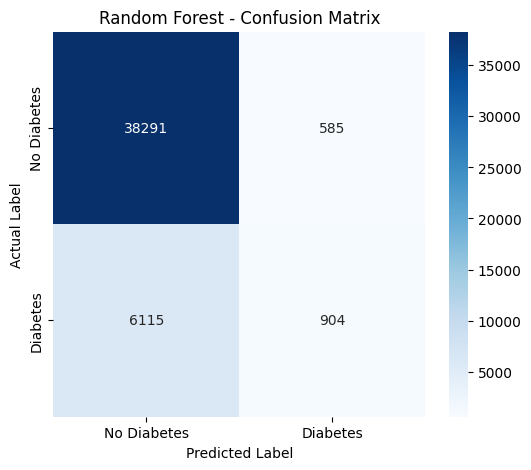

In [85]:
cm_rf = confusion_matrix(y_test, y_pred_rf)

plt.figure(figsize=(6, 5))
sns.heatmap(
    cm_rf,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["No Diabetes", "Diabetes"],
    yticklabels=["No Diabetes", "Diabetes"],
)
plt.title("Random Forest - Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")
plt.show()

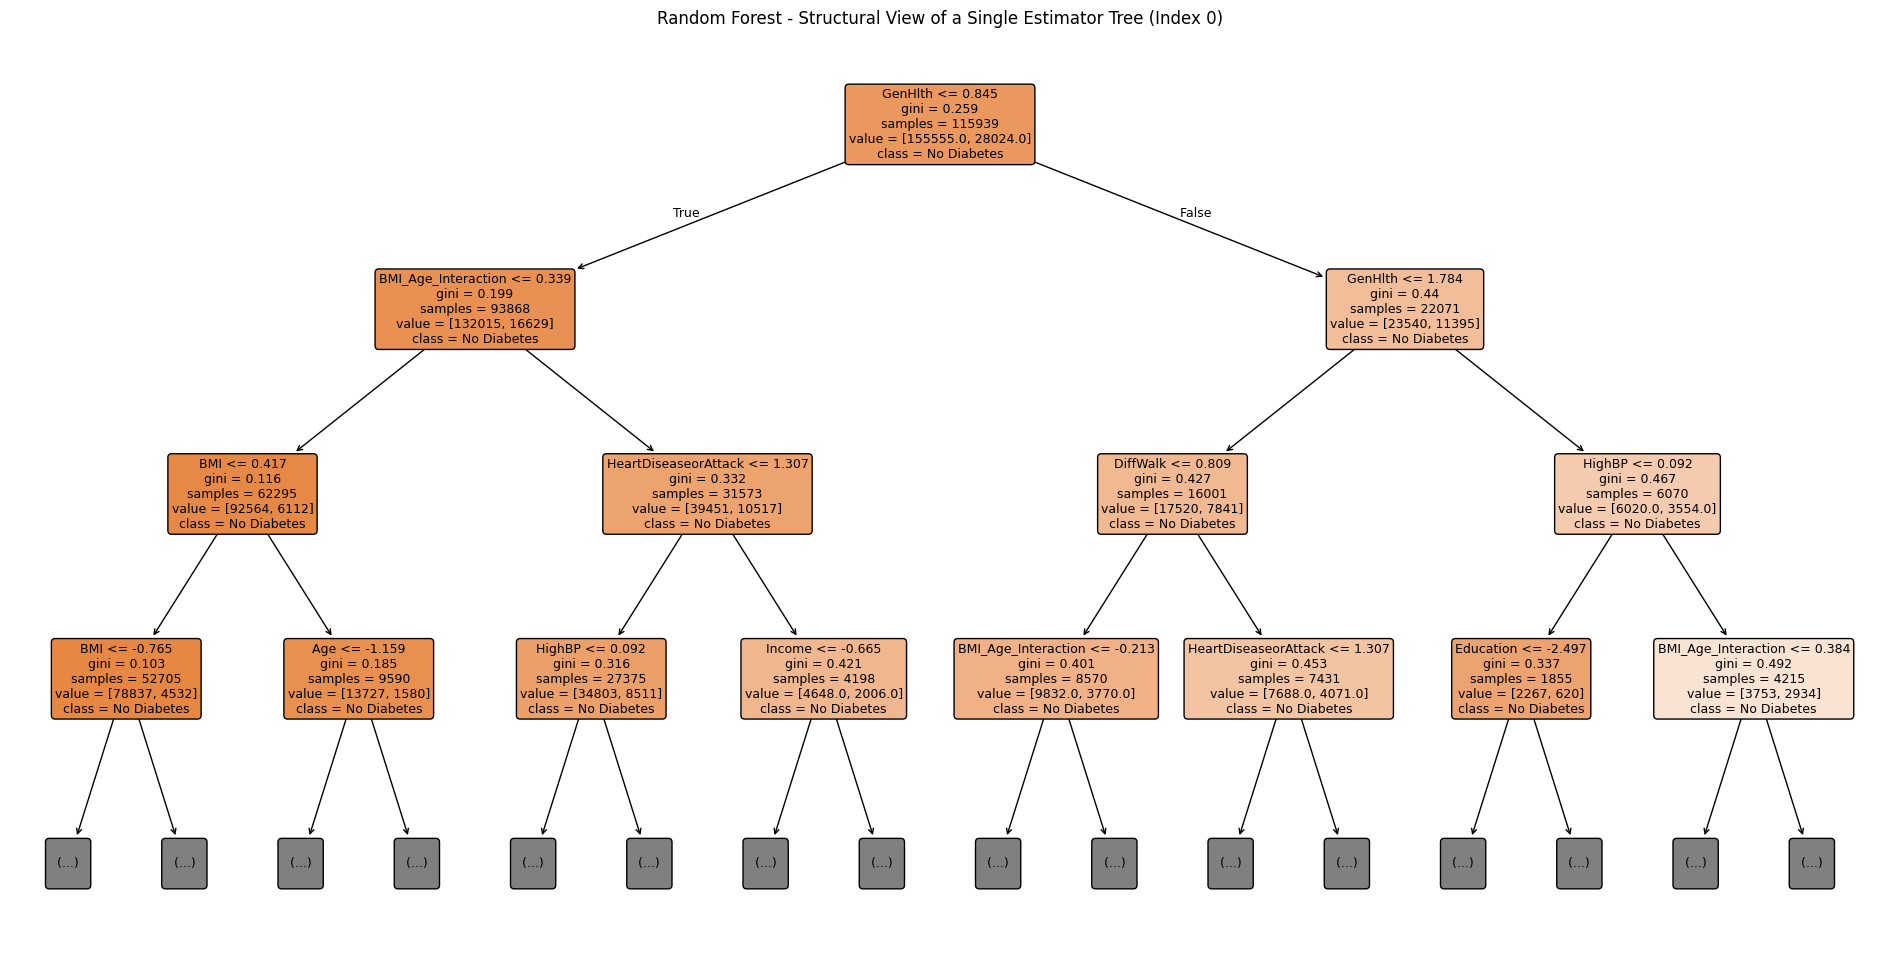

In [86]:
individual_tree = rf_model.estimators_[0]

plt.figure(figsize=(24, 12))
plot_tree(
    individual_tree,
    feature_names=X.columns,
    class_names=["No Diabetes", "Diabetes"],
    filled=True,
    rounded=True,
    max_depth=3, 
    fontsize=9,
)
plt.title("Random Forest - Structural View of a Single Estimator Tree (Index 0)")
plt.show()